In [124]:
import matplotlib.pyplot as plt
import numpy as np
import cosmopower as cp
import camb
from cosmology import Cosmology
import glass
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline


import pylevin as levin


bias_emu = cp.cosmopower_NN(restore=True, restore_filename="./../cosmopower/bias_sq_model")
power_emu = cp.cosmopower_NN(restore=True, restore_filename="./../cosmopower/pkmm_nonlin_model")



h = 0.7
Oc = 0.25
Ob = 0.05
ns = 0.96

# basic parameters of the simulation

# set up CAMB parameters for matter angular power spectrum
pars = camb.set_params(
    H0=100 * h,
    omch2=Oc * h**2,
    ombh2=Ob * h**2,
    NonLinear=camb.model.NonLinear_both,
)

[0.00000000e+00 1.00066711e-03 2.00133422e-03 ... 1.49799867e+00
 1.49899933e+00 1.50000000e+00]


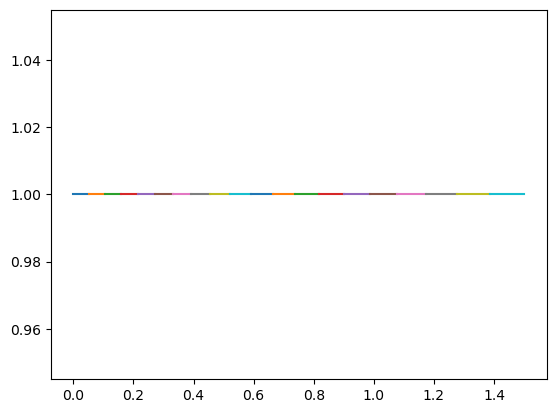

In [125]:
# get the cosmology from CAMB
cosmo_camb = Cosmology.from_camb(pars)

zet_max = 1.5
delta_chi = 200

zb = np.linspace(0,zet_max,5)
shells = glass.tophat_windows(zb)


zet_inter = np.linspace(shells[0].za[0], shells[-1].za[-1], len(shells)*len(shells[0].za))
z_of_chi = UnivariateSpline(cosmo_camb.dc(zet_inter), zet_inter, k=1, s=0)
dzdchi = z_of_chi.derivative()(cosmo_camb.dc(zet_inter))
dzdchi = UnivariateSpline(cosmo_camb.dc(zet_inter), dzdchi, k=1, s=0)

chi_of_z = UnivariateSpline(zet_inter,cosmo_camb.dc(zet_inter), k=1, s=0)


chi_b = np.linspace(0,chi_of_z(zet_max), int(chi_of_z(zet_max)/delta_chi))

zb = z_of_chi(chi_b)
shells = glass.tophat_windows(zb, dz=1e-3)



print(zet_inter)
for shell in shells:
    plt.plot(shell.za, shell.wa)

In [126]:
def get_power(T_AGN = 7.3, sigma8 = 0.8, Ob = 0.05):
    logTAGN = T_AGN
    m_nu = 0.06
    params = {'Omega_b': [Ob]*np.ones_like(zet_inter),
            'Omega_cdm' : [Oc]*np.ones_like(zet_inter),
            'h' : [h]*np.ones_like(zet_inter),
            'n_s' : [ns]*np.ones_like(zet_inter),
            'log10_T_heat' : [logTAGN]*np.ones_like(zet_inter),
            'm_nu' : [m_nu]*np.ones_like(zet_inter),
            'sigma8' : [sigma8]*np.ones_like(zet_inter),
            'alpha_B' : [0.05]*np.ones_like(zet_inter),
            'alpha_M' : [0.05]*np.ones_like(zet_inter),
            'log10_k_screen' : [-1]*np.ones_like(zet_inter),
            'z_val' : zet_inter,}
    ee = RectBivariateSpline(power_emu.modes, zet_inter, 10**((bias_emu.predictions_np(params) + power_emu.predictions_np(params)).T) ,kx=1, ky=1)
    mm = RectBivariateSpline(power_emu.modes, zet_inter, 10**(power_emu.predictions_np(params)).T ,kx=1, ky=1)
    kmin, kmax, N_int = 1e-4, 1e2, int(2e3)
    k = np.geomspace(kmin, kmax, N_int)
    x = k*8./h
    w = 3.*(np.sin(x) - x*np.cos(x) )/(x)**3.
    sigma_8_2 = np.trapezoid(mm(k,0).T*k**2*w**2,x=k)/2./np.pi**2
    ee = RectBivariateSpline(power_emu.modes, zet_inter, sigma8**2/sigma_8_2*10**((bias_emu.predictions_np(params) + power_emu.predictions_np(params)).T))
    mm = RectBivariateSpline(power_emu.modes, zet_inter, sigma8**2/sigma_8_2*10**(power_emu.predictions_np(params)).T ,kx=1, ky=1, )
    
    return ee, mm



In [137]:

def get_cells(shells,TAGN = 7.3, lmax=10000, lmax_nonlimber=1000):
    power, _ = get_power(T_AGN=TAGN)
    integral_type = 0
    N_thread = 4 # Number of threads used for hyperthreading
    logx = False # Tells the code to create a logarithmic spline in x for f(x)
    logy = False # Tells the code to create a logarithmic spline in y for y = f(x)
    n_sub = 8 #number of collocation points in each bisection
    n_bisec_max = 48 #maximum number of bisections used
    rel_acc = 1e-4 #relative accuracy target
    boost_bessel = True #should the bessel functions be calculated with boost instead of GSL, higher accuracy at high Bessel orders
    verbose = False #should the code talk to you?


    kmin, kmax, N_int = 1e-4, 1e2, int(2e3)


    ell = np.unique(np.geomspace(1,lmax,100).astype(int))
    ell_interp = np.unique(np.geomspace(1,lmax,100).astype(int))

    cells = np.zeros((len(shells),len(shells), len(ell)))
    k_int = np.geomspace(kmin, kmax, N_int)
    ell_limber = ell[ell>lmax_nonlimber]
    ell = ell[ell<=lmax_nonlimber]


    inner_int = np.zeros((len(ell), len(k_int)))


    inner_int_shells = []
    for i_shell in range(len(shells)):
        chi = cosmo_camb.dc(shells[i_shell].za)
        chi = chi[shells[i_shell].wa > 0.]
        zet = shells[i_shell].za[shells[i_shell].wa > 0.]
        weight = shells[i_shell].wa[shells[i_shell].wa > 0.]
        norm = np.trapezoid(weight,zet)
        integrand = np.sqrt(power(k_int, zet).T)*(weight*dzdchi(chi))[:,None]/norm
        for i_ell, val_ell in enumerate(ell):
            ell_values = (val_ell*np.ones_like(k_int)).astype(int)
            lp = levin.pylevin(integral_type, chi, integrand, logx, logy, N_thread, True)
            lp.set_levin(n_sub, n_bisec_max, rel_acc, boost_bessel, verbose)
            chi_min = chi[0]
            if chi_min == 0:
                chi_min = chi[1]
            lp.levin_integrate_bessel_single(chi_min*np.ones_like(k_int), chi[-1]*np.ones_like(k_int), k_int, ell_values, inner_int[i_ell,:])
        inner_int_shells.append(inner_int*k_int[None,:])
        
    inner_int_shells = np.array(inner_int_shells)
    result_levin = 2/np.pi*np.trapezoid(inner_int_shells[:, None, :,:]* inner_int_shells[None, :, :,:],k_int, axis = -1)
    cls_limber = np.zeros((len(shells),lmax, len(ell_limber)))

    for i_shell in range(len(shells)):
        chi = cosmo_camb.dc(shells[i_shell].za)
        chi = chi[shells[i_shell].wa > 0.]
        zet = shells[i_shell].za[shells[i_shell].wa > 0.]
        weight = shells[i_shell].wa[shells[i_shell].wa > 0.]
        norm = np.trapezoid(weight,zet)
        weight = weight**2/norm**2*(dzdchi(chi))**2/chi**2
        for i_ell, val_ell in enumerate(ell_limber):
            k = np.flip((val_ell + 0.5)/chi)
            integrand = np.diag(power(k, zet).T)*np.flip(weight)
            cls_limber[i_shell,i_shell,i_ell] = -np.trapezoid(integrand[:-1],np.flip(chi[1:]),axis = -1)
    cls_final = np.zeros((len(shells), len(shells), len(ell_interp)))
    for i_shell in range(len(shells)):
        for j_shell in range(i_shell,len(shells)):
            aux_cell = np.zeros(len(cells[0,0,:]))
            aux_cell[:len(ell)] = result_levin[i_shell, j_shell,:]
            aux_cell[len(ell):] = cls_limber[i_shell, j_shell,:]
            cls_final[i_shell,j_shell, : ] = UnivariateSpline(ell_interp, aux_cell, k =1,s = 0, ext=1)(ell_interp)
            cls_final[j_shell,i_shell, : ] = cls_final[i_shell,j_shell, : ]
    return ell_interp, cls_final

In [138]:
T_AGN = np.linspace(6.8,8.8, 20)
C_ells_agn = []
for i in range(len(T_AGN)):
    print(i)
    ell, cells = get_cells(shells=shells,lmax_nonlimber=1000, TAGN=T_AGN[i])
    C_ells_agn.append(cells)

0


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_70867/2695452761.py:57: RuntimeWarning: divide by zero encountered in divide
  weight = weight**2/norm**2*(dzdchi(chi))**2/chi**2
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_70867/2695452761.py:59: RuntimeWarning: divide by zero encountered in divide
  k = np.flip((val_ell + 0.5)/chi)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [139]:
C_ells_agn = np.array(C_ells_agn)



In [140]:
np.savez("C_ells_shells_T_AGN", ell=ell, C_ells = C_ells_agn, shell_boundaries_z = zb,T_AGN = T_AGN, sigma_8_fid = [0.8])


In [56]:

# apply discretisation to the full set of spectra:
# - HEALPix pixel window function (`nside=nside`)
# - maximum angular mode number (`lmax=lmax`)
# - number of correlated shells (`ncorr=3`)
nbins = len(shells)
nside = 256
lmax = nside
cls_new = [cells[j, i] for i, j in glass.spectra_indices(nbins)] # These are in glass ordering

# interpolate the c_ells
cls_new = glass.arraytools.ndinterp(np.log(np.arange(ell[-1]+1)), np.log(ell), cls_new)


cls_binned = glass.discretized_cls(cls_new, nside=nside, lmax=ell[-1])


# set up lognormal fields for simulation
fields = glass.lognormal_fields(shells)

# compute Gaussian spectra for lognormal fields from discretised spectra
gls = glass.solve_gaussian_spectra(fields, cls_binned)

# this generator will yield the matter fields in each shell
matter = glass.generate(fields, gls, nside)

/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_70867/4275345754.py:11: RuntimeWarning: divide by zero encountered in log
  cls_new = glass.arraytools.ndinterp(np.log(np.arange(ell[-1]+1)), np.log(ell), cls_new)


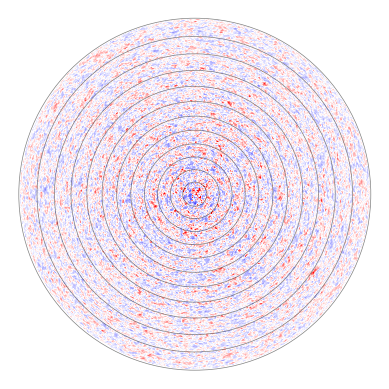

In [57]:
import healpy as hp

# make a 2d grid in redshift
n = 2000
zend = 1.05 * zb[-1]
x, y = np.mgrid[-zend : zend : 1j * n, -zend : zend : 1j * n]
z = np.hypot(x, y)
grid = np.full(z.shape, np.nan)

# set up the plot
ax = plt.subplot(111)
ax.axis("off")

# simulate and project an annulus of each matter shell onto the grid
for i, delta_i in enumerate(matter):
    zmin, zmax = zb[i], zb[i + 1]
    g = (zmin <= z) & (z < zmax)
    zg = np.sqrt(1 - (z[g] / zmax) ** 2)
    theta, phi = hp.vec2ang(np.transpose([x[g] / zmax, y[g] / zmax, zg]))

    grid[g] = hp.get_interp_val(delta_i, theta, phi)
    ax.add_patch(
        plt.Circle((0, 0), zmax / zend, fc="none", ec="k", lw=0.5, alpha=0.5, zorder=1),
    )

# show the grid of shells
ax.imshow(grid, extent=[-1, 1, -1, 1], zorder=0, cmap="bwr", vmin=-1, vmax=1)

# show the resulting plot
plt.show()